# What's Really Inside the S&P 500?
## Phase 3: Concentration Analysis

**Central Question:** What's really inside the S&P 500? Analyzing the composition, concentration, and turnover of the world's most popular index to understand what investors are actually buying.

---

### Overview

In Phase 2, I found that Information Technology dominates the S&P 500 - roughly 30% of the total market cap despite having fewer companies than Industrials and Financials. That was the *sector* view.

Now zooming in further and aksing the *company-level* question: how much of the index is controlled by just a handful of individual stocks? If the top 10 companies make up a third of the entire index, what does that mean for the 490+ other, and for investors who think they're getting diversification?

This phase covers four things:

1. **Top-N concentration snapshots** - What share of total market cap do the top 5, 10, and 25 companies hold?
2. **Cumulative weight curve** - A visual showing how quickly market cap accumulates as you move down the ranked list of companies.
3. **Top 20 vs. the index** - Comparing the growth of the biggest stocks against the S&P 500 as a whole.
4. **Herfindahl-Hirschman Index (HHI)** - A standard economic measure that captures concentration in a single number.

---
## Step 1: Libraries and Data

Libraries used:
- **pandas** - data manipulation and analysis
- **matplotlib/seaborn** - data visualization 

Datasets used:
- `sp500_companies_market_cap.csv` - market cap for all 503 companies
- `top20_price_history.csv` - daily close prices for the top 20 companies by market cap
- `sp500_index_history.csv` - 10 years of daily S&P 500 index prices


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
companies = pd.read_csv('data/sp500_companies_market_cap.csv')
top20_prices = pd.read_csv('data/top20_price_history.csv')
sp500 = pd.read_csv('data/sp500_index_history.csv')

In [47]:
print(sp500.head(5))
print(f'\nColumns: {sp500.columns.tolist()}')
print(f'Shape: {sp500.shape}')

        Price              Close                High               Low  \
0      Ticker              ^GSPC               ^GSPC             ^GSPC   
1        Date                NaN                 NaN               NaN   
2  2016-03-28  2037.050048828125  2042.6700439453125   2031.9599609375   
3  2016-03-29  2055.010009765625   2055.909912109375  2028.31005859375   
4  2016-03-30  2063.949951171875     2072.2099609375  2058.27001953125   

                 Open      Volume  
0               ^GSPC       ^GSPC  
1                 NaN         NaN  
2  2037.8900146484375  2809090000  
3             2035.75  3822330000  
4    2058.27001953125  3590310000  

Columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
Shape: (2515, 6)


In [48]:
# Drop the two junk rows (Ticker row and Date/NaN row)
sp500 = sp500.drop([0, 1]).reset_index(drop=True)

print(sp500.head())

        Price              Close                High               Low  \
0  2016-03-28  2037.050048828125  2042.6700439453125   2031.9599609375   
1  2016-03-29  2055.010009765625   2055.909912109375  2028.31005859375   
2  2016-03-30  2063.949951171875     2072.2099609375  2058.27001953125   
3  2016-03-31  2059.739990234375      2067.919921875   2057.4599609375   
4  2016-04-01  2072.780029296875   2075.070068359375  2043.97998046875   

                 Open      Volume  
0  2037.8900146484375  2809090000  
1             2035.75  3822330000  
2    2058.27001953125  3590310000  
3    2063.77001953125  3715280000  
4     2056.6201171875  3749990000  


### 1A: Data Check

Confirming all three datasets loaded correctly

In [5]:
print(f'Companies: {companies.shape}')
print(f'Top 20 prices: {top20_prices.shape}')
print(f'S&P 500 index: {sp500.shape}')

Companies: (503, 9)
Top 20 prices: (2513, 21)
S&P 500 index: (2515, 6)


---

## Step 2: Top-N Concentration Snapshots

The simplest and most powerful way to show concentration: answering the question "what percentage of the entire index do the top N companies represent?"

The data is already in `companies', each row has a company and its `market_cap`. I need to:
1. Sort by `market_cap` descending
2. Calculate the total market cap of the entire index
3. Sum the market cap for the top 5, 10, and 25
4. Divide each by the total to get percentages

These numbers are the headline finding of this phase.

### 2A: Sort and calculate total market cap

In [1]:
print(companies.columns.tolist())

NameError: name 'companies' is not defined

In [8]:
#Sorting companies by market cap, largest first
companies = companies.sort_values('market_cap', ascending=False).reset_index(drop=True)

#Total market cap of the entire index
total_market_cap = companies['market_cap'].sum()
print(f'Total S&P 500 market cap: ${total_market_cap/1e12:.2f} trillion')

Total S&P 500 market cap: $62.58 trillion


### 2B: Top-N percentages

Calculating what percentage of the total index market cap the top 5, top 10, and top 25 companies hold.

In [11]:
#Calculating the top-N concentration
for n in [5, 10, 25]:
    top_n_cap = companies.head(n)['market_cap'].sum()
    pct = (top_n_cap / total_market_cap) * 100
    print(f'Top {n:>2} companies: ${top_n_cap / 1e12:.2f}T -> {pct:.1f}% of the index')
    
#The actual top 10
print(f'Top 10 companies:')
print(companies[['ticker', 'company', 'market_cap_billions']].head(10).to_string(index=False))

Top  5 companies: $17.39T -> 27.8% of the index
Top 10 companies: $24.89T -> 39.8% of the index
Top 25 companies: $32.90T -> 52.6% of the index
Top 10 companies:
ticker                 company  market_cap_billions
  NVDA                  Nvidia          4161.988461
  AAPL              Apple Inc.          3716.958388
 GOOGL Alphabet Inc. (Class A)          3398.289588
  GOOG Alphabet Inc. (Class C)          3396.111696
  MSFT               Microsoft          2720.027378
  AMZN                  Amazon          2227.925418
  AVGO                Broadcom          1467.021263
  TSLA             Tesla, Inc.          1396.317356
  META          Meta Platforms          1385.032712
 BRK-B      Berkshire Hathaway          1025.096024


### 2C: Top-N concentration visual

Chart for each group (top 5, 10, 25)



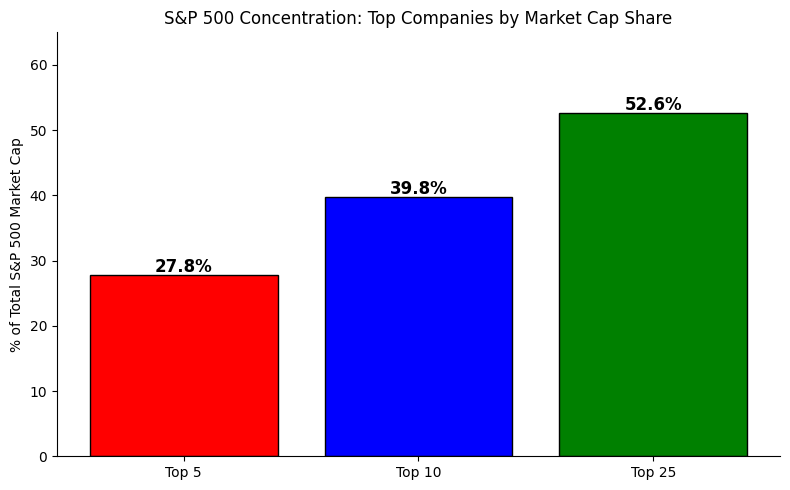

In [28]:
#Concentration bar chart
labels = ['Top 5', 'Top 10', 'Top 25']
percentages = []

for n in [5, 10, 25]:
    pct = (companies.head(n)['market_cap'].sum() / total_market_cap) * 100
    percentages.append(pct)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, percentages, color=['Red', 'Blue', 'Green'], edgecolor='black')

#Labeling each bar
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, 
            f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('% of Total S&P 500 Market Cap')
ax.set_title('S&P 500 Concentration: Top Companies by Market Cap Share')
ax.set_ylim(0, 65)
sns.despine()
plt.tight_layout()
plt.show()

---
## Step 3: Cumulative Weight Curve

The Top-N snapshot gives three data points. The cumulative weight curve on the other hand tell the full story. It shows how the market cap accumulates as you go from the biggest company down to the smallest.

If the S&P 500 were perfectly equal, this curve would be a straight diagonal line. But in reality, the curve shoots up steeply at the start and then flattens out. This is because the top companies are enormous and the bottom hundreds of companies are tiny by comparison.

### 3A: Cumulative weights

In [33]:
# Caluculating each company's weight as a percentage of the total market cap
companies['weight'] = (companies['market_cap'] / total_market_cap) * 100

# Cumulative weight (running total from #1 to #503)
companies['cumulative_weight'] = companies['weight'].cumsum()

# Checking the rows and making sure the last value is 100
print(companies[['ticker', 'company', 'weight', 'cumulative_weight']].head(10))
print(f"\nFinal cumulative weight: {companies['cumulative_weight'].iloc[-1]:.2f}%")

  ticker                  company    weight  cumulative_weight
0   NVDA                   Nvidia  6.650487           6.650487
1   AAPL               Apple Inc.  5.939369          12.589855
2  GOOGL  Alphabet Inc. (Class A)  5.430164          18.020020
3   GOOG  Alphabet Inc. (Class C)  5.426684          23.446704
4   MSFT                Microsoft  4.346362          27.793065
5   AMZN                   Amazon  3.560026          31.353092
6   AVGO                 Broadcom  2.344169          33.697261
7   TSLA              Tesla, Inc.  2.231191          35.928452
8   META           Meta Platforms  2.213159          38.141611
9  BRK-B       Berkshire Hathaway  1.638012          39.779623

Final cumulative weight: 100.00%


### 3B: Cumulative weight curve visual

Plotting the cumulative weight (0-100%) against company rank (1-503), with a diagonal reference line showing perfect equality and horizontal markers at the 50% and 80% thresholds.

*Signature chart of the concentration analysis*



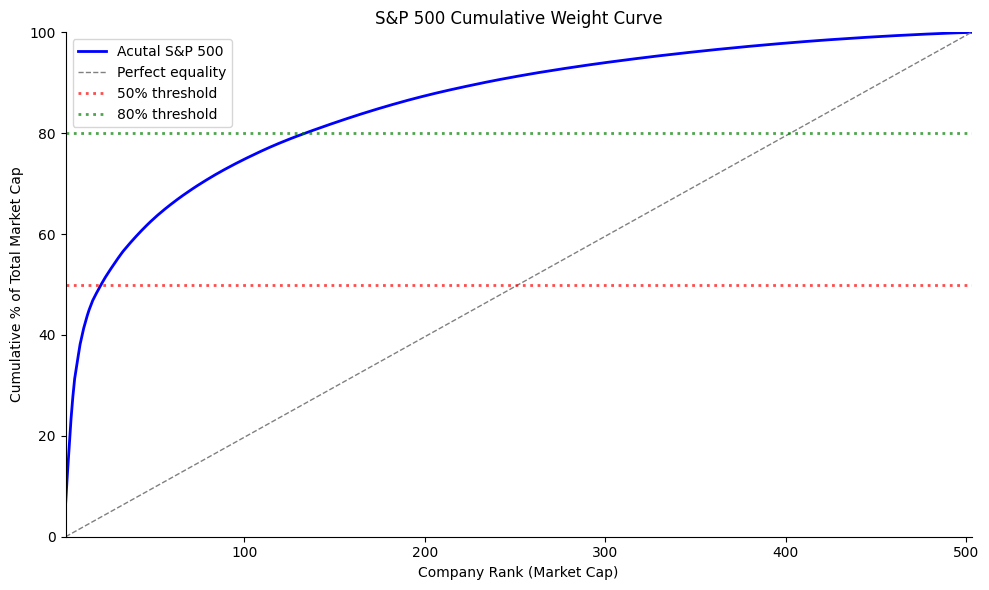

In [39]:
# Ranking companies from 1 to 503
rank = range(1, len(companies) + 1)

fig, ax = plt.subplots(figsize=(10, 6))

# The actual cumulative weight curve
ax.plot(rank, companies['cumulative_weight'], color='blue', linewidth=2, label='Acutal S&P 500')

# Hypothetical on if they were all equal
ax.plot([1, len(companies)], [0, 100], color='gray', linestyle='--', linewidth=1, label='Perfect equality')

# Reference lines at 50% and 80%
ax.axhline(y=50, color='red', linestyle=':', linewidth=2, alpha=0.7, label='50% threshold')
ax.axhline(y=80, color='green', linestyle=':', linewidth=2, alpha=0.7, label='80% threshold')

ax.set_xlabel('Company Rank (Market Cap)')
ax.set_ylabel('Cumulative % of Total Market Cap')
ax.set_title('S&P 500 Cumulative Weight Curve')
ax.legend()
ax.set_xlim(1, len(companies))
ax.set_ylim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()

In [41]:
# Companies to reach 50% and 80%
c50 = (companies['cumulative_weight'] >= 50).idxmax() + 1
c80 = (companies['cumulative_weight'] >= 80).idxmax() + 1

print(f'Companies needed to reach 50% of index: {c50}')
print(f'Companies needed to reach 80% of index: {c80}')

Companies needed to reach 50% of index: 21
Companies needed to reach 80% of index: 134


---
## Step 4: Top 20 vs. the S&P 500 Index

I've shown that the biggest companies dominate the index by size. But do they also dominate by performance?

To compare, I need to **normalize** both datasets to a common starting point. This means converting every price to a percentage of its first value, so everything starts at 100. Similar to what I did when normalizing the sector ETFs towards the end of phase 2.

Datasets:
`top20_price_history.csv` and `sp500_index-history.csv`

### 4A: Preparing and normalizing the data

The S&P 500 index file had a messy multi-level header from `yfinance`, cleaning that first, then calculating an equal-weighted daily average across the top 20 stocks and normalizing both series to start at 100.

In [68]:
#Cleaning the messy yfinance header format
sp500 = pd.read_csv('data/sp500_index_history.csv', skiprows=[1,2])
sp500 = sp500.rename(columns={'Price' : 'Date'})
sp500['Date'] = pd.to_datetime(sp500['Date'])
sp500 = sp500.set_index('Date')
sp500 = sp500.apply(pd.to_numeric)

print(sp500.head())
print(f'\nDtypes:\n{sp500.dtypes}')

                  Close         High          Low         Open      Volume
Date                                                                      
2016-03-28  2037.050049  2042.670044  2031.959961  2037.890015  2809090000
2016-03-29  2055.010010  2055.909912  2028.310059  2035.750000  3822330000
2016-03-30  2063.949951  2072.209961  2058.270020  2058.270020  3590310000
2016-03-31  2059.739990  2067.919922  2057.459961  2063.770020  3715280000
2016-04-01  2072.780029  2075.070068  2043.979980  2056.620117  3749990000

Dtypes:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [69]:
# Top 20 prices file
top20_prices = pd.read_csv('data/top20_price_history.csv', parse_dates=['Date'], index_col='Date')

# Calculating the equal-weighted average of top 20 stocks per day
top20_avg = top20_prices.mean(axis=1)

# Normalizing so both start at 100
top20_norm = (top20_avg / top20_avg.iloc[0] * 100)
sp500_norm = (sp500['Close'] / sp500['Close'].iloc[0] * 100)

In [70]:
top20_norm.head()

Date
2016-03-28    100.000000
2016-03-29    101.224190
2016-03-30    101.736512
2016-03-31    101.462814
2016-04-01    102.424066
dtype: float64

In [71]:
sp500_norm.head()

Date
2016-03-28    100.000000
2016-03-29    100.881665
2016-03-30    101.320532
2016-03-31    101.113863
2016-04-01    101.754006
Name: Close, dtype: float64

In [72]:
print(f'Top 20 normalized start: {top20_norm.iloc[0]}')
print(f'S&P 500 normalized start: {sp500_norm.iloc[0]}')
print(f'\nTop 20 normalized end: {top20_norm.iloc[-1]:.2f}')
print(f'S&P 500 normalized end: {sp500_norm.iloc[-1]:.2f}')

Top 20 normalized start: 100.0
S&P 500 normalized start: 100.0

Top 20 normalized end: 657.03
S&P 500 normalized end: 321.86


### 4B: Top 20 vs. S&P 500 visual

Both normalized series. The x-axis is time, the y-axis is the normalized value (starting at 100). If the Top 20 line sits above the index line, the biggest companies have outperformed the broader market.

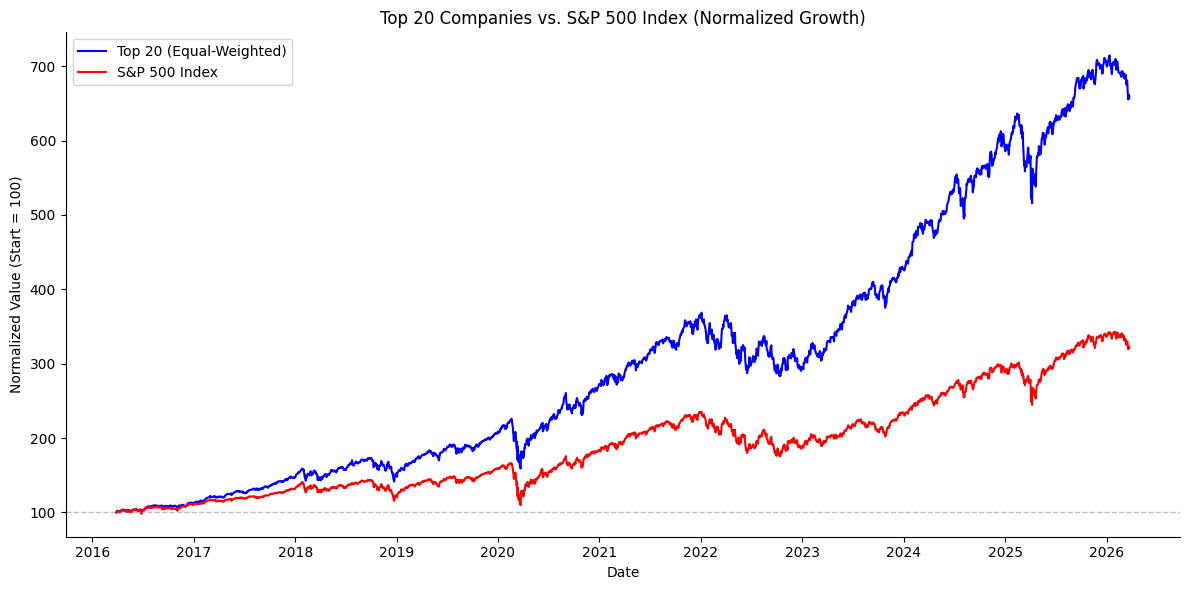

In [74]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(top20_norm.index, top20_norm, color='blue', linewidth=1.5, label='Top 20 (Equal-Weighted)')
ax.plot(sp500_norm.index, sp500_norm, color='red', linewidth=1.5, label='S&P 500 Index')
ax.axhline(y=100, color='gray', linestyle="--", linewidth=1, alpha=0.5)

ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value (Start = 100)')
ax.set_title('Top 20 Companies vs. S&P 500 Index (Normalized Growth)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## Step 5: Herfindahl-Hirschman Index (HHI)

The HHI is a standard economic measure of market concentration. Regulators (including the U.S. Department of Justice) use it to evaluate mergers and assess competitive markets.

**How it works:** Take each company's market share (as a percentage of the total), square it, and sum all the squared values. Squaring amplifies the contribution of large companies disproportionately, which is exactly what a concentration measure should do.

- **Below 1,500** → Unconcentrated
- **1,500 – 2,500** → Moderately concentrated
- **Above 2,500** → Highly concentrated

The maximum possible HHI is 10,000 (one company with 100% share: 100² = 10,000). If all 503 companies were equal, the HHI would be about 20. The actual number tells us how far the S&P 500 is from equal weighting.

### 5A: Calculating S&P 500's HHI
Squaring each company's weight and summing the results, then comparing to the equal-weight baseline and identifying the DOJ category.

In [78]:
#Calculating HHI (sum of squared weights)
companies['weight_squared'] = companies['weight'] ** 2
hhi = companies['weight_squared'].sum()

#What HHI would be if all 503 companies were equal
equal_hhi = (100 / len(companies)) ** 2 * len(companies)

#DOJ category
if hhi < 1500:
    category = 'Unconcentrated'
elif hhi < 2500:
    category = 'Moderately Concentrated'
else:
    category = 'Highly Concentrated'

print(f'Actual S&P 500 HHI: {hhi:.2f}')
print(f'Equal-weight HHI: {equal_hhi:.2f}')
print(f'DOJ Category: {category}')

Actual S&P 500 HHI: 210.00
Equal-weight HHI: 19.88
DOJ Category: Unconcentrated


### 5B: HHI contribution by company visual (top 10)

Showing how much each of the top 10 companies contributes to the total HHI, making the squaring effect concrete.

In [83]:
#Top 10 companies by HHI contribution
top10_hhi = companies[['ticker', 'company', 'weight', 'weight_squared']].head(10)
top10_hhi

,ticker,company,weight,weight_squared
0,NVDA,Nvidia,6.650487,44.228976
1,AAPL,Apple Inc.,5.939369,35.276098
2,GOOGL,Alphabet Inc. (Class A),5.430164,29.486683
3,GOOG,Alphabet Inc. (Class C),5.426684,29.448900
4,MSFT,Microsoft,4.346362,18.890859
5,AMZN,Amazon,3.560026,12.673788
6,AVGO,Broadcom,2.344169,5.495130
7,TSLA,"Tesla, Inc.",2.231191,4.978212
8,META,Meta Platforms,2.213159,4.898072
9,BRK-B,Berkshire Hathaway,1.638012,2.683084


In [89]:
#Percentage that the top 10 account for in the total HHI 
top10_hhi_pct = (top10_hhi['weight_squared'].sum() / hhi) * 100
print(f'Top 10 HHI contribution: {top10_hhi["weight_squared"].sum():.2f} out of {hhi:.2f} ({top10_hhi_pct:.1f}%)')

Top 10 HHI contribution: 188.06 out of 210.00 (89.6%)


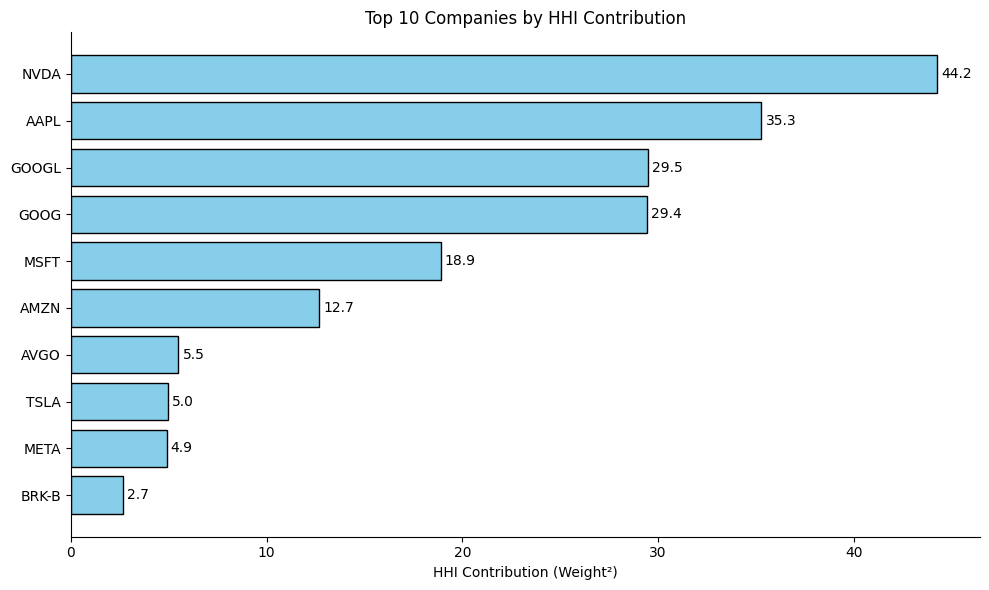

In [98]:
#The horizontal bar chart
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(top10_hhi['ticker'][::-1], top10_hhi['weight_squared'][::-1], color='skyblue', edgecolor='black')

ax.bar_label(bars, labels=[f'{w:.1f}' for w in top10_hhi['weight_squared'][::-1]], 
            padding=3, fontsize=10)

ax.set_xlabel('HHI Contribution (Weight²)')
ax.set_title('Top 10 Companies by HHI Contribution')
sns.despine()
plt.tight_layout()
plt.show()         

---
## Key Takeaways

After this concentration analysis, here are a few observations:

- I came into the this phase already suspicious after the sector analysis showed Technology holding nearly 30% of the index's market cap. I expected concentration at the company level too, but the numbers were more extreme than I anticipated.

- The top 5 companies alone hold 27.8% of the entire index. The top 10 hold 39.8%, and it only takes 25 companies to cross the 50% mark. That means the other 478 companies combined hold less than half the index. It takes just 21 companies to reach 50%, and 134 to reach 80% — leaving the bottom 369 companies to split the remaining 20%.

- Over the past 10 years, the top 20 companies grew roughly 557% compared to the S&P 500's 222%. The biggest stocks aren't just big, they're growing far faster than the rest of the index, which means concentration is increasing over time, not just sitting still.

- The HHI came in at 210, which the DOJ would classify as "unconcentrated." That surprised me at first, but the DOJ thresholds were designed for industries with a handful of players, not a 500-company index. The more telling number is the comparison: the actual HHI is more than 10x the equal-weight baseline of 19.88. And the top 10 companies drive 89.6% of the total HHI score, while the other 493 companies contribute just over 10%.

- 9 out of the 10 largest companies are in tech. Berkshire Hathaway is the only exception. Combined with what I found in Phase 2, the picture is clear, the S&P 500 isn't a diversified bet across 500 companies. It's a portfolio heavily concentrated in a handful of tech giants.


**Next: Phase 4 - Historical Context & Major Events**